In [1]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 34.1 MB/s eta 0:00:00


In [2]:
def obtener_datos(u ,e ,a1, a2, b1, b2, C, type='ARX'):
  N = len(u)
  y = np.zeros_like(u)
  for k in range(2, N):
    y[k] = a1*y[k-1] + a2*y[k-2] + b1*u[k-1]

  return y

In [3]:
import control as ctrl
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import math
# Formamos la TF discreta identificada: B(z)/A(z)
# A(z) = 1 + a1 z^-1 + a2 z^-2
# B(z) =      0 + b1 z^-1 + b2 z^-2  (el término z^0 es cero)

#Estos son los parametros estimados en nuestra planta real por RLS en modelo ARX

a0 = 1.8929854463139977
a1 = -0.9012777069124254
b0 = 3.4320353114814736e-05
b1 = 0

Ts = 0.02
A_d = [1.0, -a0, -a1]
B_d = [0.0, b0, b1]
Gd = ctrl.TransferFunction(B_d, A_d, Ts)
Gd.name="Planta"
print(ctrl.poles(Gd))



# Especificación del modelo
# parámetros
wn = 30.0         # rad/s (natural frequency)
zeta = 0.9     # damping

# polos continuos
p1 = -zeta*wn + 1j*wn*math.sqrt(1 - zeta**2)
p2 = -zeta*wn - 1j*wn*math.sqrt(1 - zeta**2)

# polos discretos (mapeo exacto s -> z)
z1 = np.exp(p1 * Ts)
z2 = np.exp(p2 * Ts)

[0.94649272+0.07368332j 0.94649272-0.07368332j]


[np.float64(98.85471846907916)]
Ganancia de continua = 1.0
Modelo a seguir <TransferFunction>: Modelo
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

              0.006
  ------------------------------
  z^3 - 2.4 z^2 + 1.91 z - 0.504


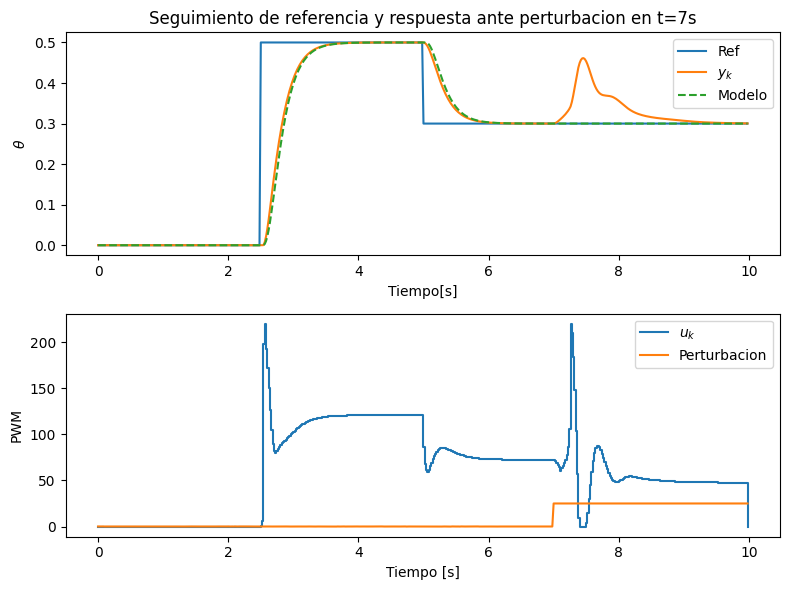

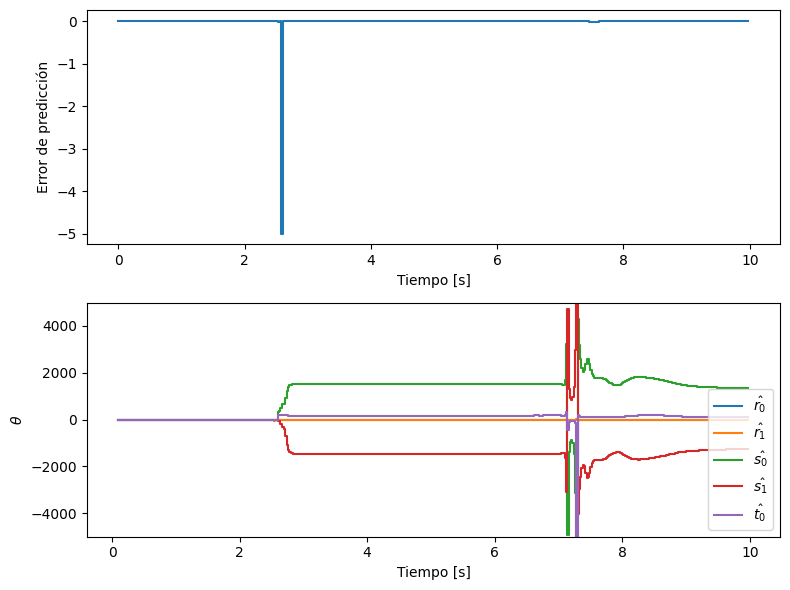

[ 1349.48086707 -1266.01552775]


In [23]:
Acl = np.poly([z1, z2, 0.05])
Acl = np.poly([0.7,0.8,0.9])
# --- Simulación ---
t = np.arange(0, 10, Ts)
n_steps = len(t)

# Señales
np.random.seed(0)
sigma_v = 0.03
v = sigma_v*np.random.randn(n_steps)
#v[len(v)//:] = v[len(v)//8:] + 0.2
v[350:] = 25
#v = sigma_v*np.ones(n_steps)
y = np.zeros(n_steps)
r = 0.5*np.ones_like(y)  # de 0 a 1
r[:len(y)//4] = 0
r[len(y)//2:] = 0.3
yf = np.zeros_like(y)
y_hat = np.zeros_like(y)
err = np.zeros_like(y)
u = np.zeros_like(y)
uf = np.zeros_like(y)
param_hist = []


lambda_ = 0.95

# Especificación de la estructura del controlador
nr = 2
ns = 2

# Inicialización del estimador
theta_hat = np.ones(nr+ns)/10
P = 100 * np.eye(nr+ns)          # matriz de incertidumbre grande

for k in range(ns+nr, n_steps-1):
      # Nota memoria: y[k] = salida actual   u[k] entrada actual
      ### PRIMER PASO: FILTRAR LAS SENALES Yf y Uf.
      # Calculo las señales filtradas yf, uf
      yf[k] = -np.array(Acl[1:]) @ np.array(yf[k-1:k-len(Acl):-1]) + y[k-1]
      uf[k] = -np.array(Acl[1:]) @ np.array(uf[k-1:k-len(Acl):-1]) + u[k-1]

      # Armo el regresor
      phi = np.concatenate((uf[k:k-nr:-1], yf[k:k-ns:-1]))   # vector de regresores

      # Calculo y estimado y el error de estimación
      y_hat[k] = phi @ theta_hat
      err[k] = y[k] - y_hat[k]

      # Actualizo la estimación de parámetros
      K = P @ phi / (lambda_ + phi.T @ P @ phi)
      theta_hat = theta_hat + K * err[k]
      P = (P - np.outer(K, phi) @ P) / lambda_

      # Calculo los polinomios del controlador
      R_tilde = theta_hat[0:nr]
      S_tilde = theta_hat[nr:nr+ns]


      R = R_tilde/R_tilde[0]
      S = S_tilde/R_tilde[0]
      T = [np.sum(Acl)/R_tilde[0]]

      # Almaceno los parámetros estimados para graficar luego
      param = theta_hat.copy()
      param /= param[0]
      param = np.append(param.flatten(), T[0])
      param_hist.append(param)

      # Calcular u[k] según controlador discreto:
      # R(q)u = T(q)r - S(q)y
      # => u[k] = (1/R0) * ( ... )
      # Calculo la acción de control del STR
      u[k] = (np.dot(T,r[k:k-len(T):-1])
              - np.dot(S, y[k:k-len(S):-1])
              - np.dot(R[1:], u[k-1:k-len(R):-1]))/R[0]

      if u[k] > 220:
        u[k] = 220
      if u[k] < 0:
        u[k] = 0

      # Simular dinámica continua con entrada u[k]
      # Equivale a usar un ZOH
      resp = a0*y[k] + a1*y[k-1] + b0*(u[k] + v[k])
      y[k+1] = resp  # tomar valor al final del período

param_hist = np.array(param_hist)
print(T)
Gm = ctrl.TransferFunction(np.sum(Acl),Acl,dt=Ts)
Gm.name='Modelo'
print(f'Ganancia de continua = {np.sum(Acl)/np.sum(Acl)}')
print('Modelo a seguir',Gm)

# Para comparar con el modelo
t_m,y_m = ctrl.forced_response(Gm,t,U=r)

plt.figure(figsize=(8,6))
plt.subplot(2,1,1)
plt.title(f'Seguimiento de referencia y respuesta ante perturbacion en t=7s')
plt.plot(t,r,label='Ref')
plt.plot(t,y,label='$y_k$')
plt.plot(t_m,y_m,'--',label='Modelo')
plt.xlabel('Tiempo[s]')
plt.ylabel('$\\theta$')
plt.legend()
plt.subplot(2,1,2)
plt.step(t,u,where='post',label='$u_k$')
plt.plot(t,v,label='Perturbacion')
plt.ylabel('PWM')
plt.xlabel('Tiempo [s]')
plt.tight_layout()
plt.legend()


plt.figure(figsize=(8,6))
plt.subplot(211)
plt.xlabel('Tiempo [s]')
plt.step(t,err,where='post')
plt.ylabel('Error de predicción')
plt.subplot(212)

for idx_nr in range(0,nr):
    plt.step(t[-len(param_hist):],param_hist[:,idx_nr], label=f"$\\hat{{r_{idx_nr}}}$",where='post')
for idx_ns in range(0,ns):
    plt.step(t[-len(param_hist):],param_hist[:,nr+idx_ns], label=f"$\\hat{{s_{idx_ns}}}$",where='post')

plt.step(t[-len(param_hist):],param_hist[:,nr+ns], label=f"$\\hat{{t_0}}$",where='post')

plt.legend()
plt.xlabel('Tiempo [s]')
plt.ylabel('$\\theta$')
plt.ylim([-5000, 5000])
plt.tight_layout()
plt.show()
print(S)




[np.float64(109.22829750708138)]
Ganancia de continua = 1.0
Modelo a seguir <TransferFunction>: Modelo
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.02

              0.006
  ------------------------------
  z^3 - 2.4 z^2 + 1.91 z - 0.504


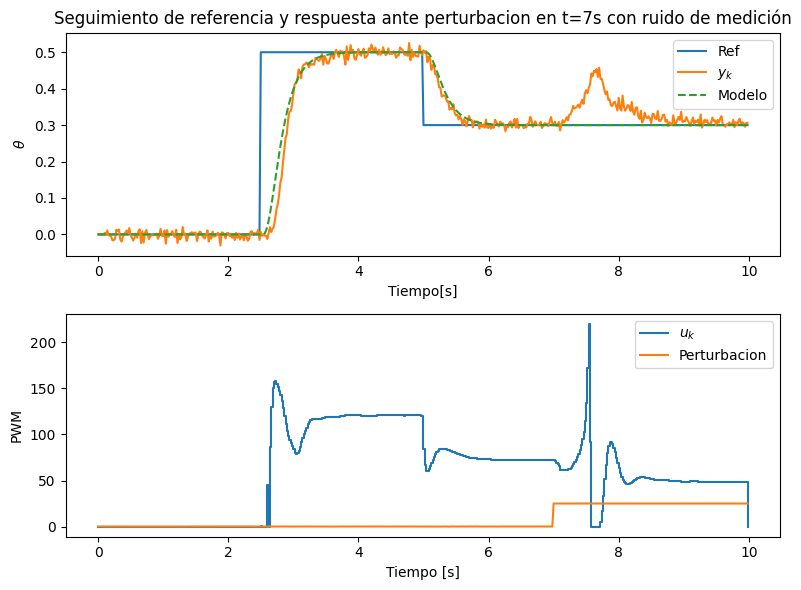

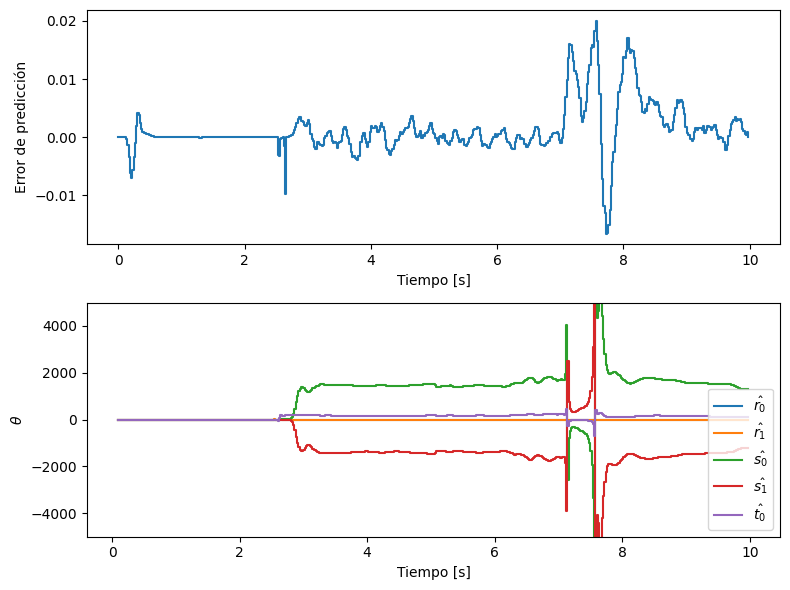

In [26]:
Acl = np.poly([0.7, 0.8,0.9])
# --- Simulación ---
t = np.arange(0, 10, Ts)
n_steps = len(t)

# Señales
np.random.seed(0)
sigma_v = 0.03
v = sigma_v*np.random.randn(n_steps)
#v[len(v)//:] = v[len(v)//8:] + 0.2
v[350:] = 25
#v = sigma_v*np.ones(n_steps)
y = np.zeros(n_steps)
r = 0.5*np.ones_like(y)  # de 0 a 1
r[:len(y)//4] = 0
r[len(y)//2:] = 0.3
yf = np.zeros_like(y)
y_n = np.zeros_like(y)
y_hat = np.zeros_like(y)
err = np.zeros_like(y)
u = np.zeros_like(y)
uf = np.zeros_like(y)
param_hist = []


lambda_ = 0.95

# Especificación de la estructura del controlador
nr = 2
ns = 2

# Inicialización del estimador
theta_hat = np.ones(nr+ns)/10
P = 100 * np.eye(nr+ns)          # matriz de incertidumbre grande

for k in range(ns+nr, n_steps-1):
      # Nota memoria: y[k] = salida actual   u[k] entrada actual

      # Calculo las señales filtradas yf, uf
      yf[k] = -np.array(Acl[1:]) @ np.array(yf[k-1:k-len(Acl):-1]) + y_n[k-1]
      uf[k] = -np.array(Acl[1:]) @ np.array(uf[k-1:k-len(Acl):-1]) + u[k-1]

      # Armo el regresor
      phi = np.concatenate((uf[k:k-nr:-1], yf[k:k-ns:-1]))   # vector de regresores

      # Calculo y estimado y el error de estimación
      y_hat[k] = phi @ theta_hat
      err[k] = y[k] - y_hat[k]

      # Actualizo la estimación de parámetros
      K = P @ phi / (lambda_ + phi.T @ P @ phi)
      theta_hat = theta_hat + K * err[k]
      P = (P - np.outer(K, phi) @ P) / lambda_

      # Calculo los polinomios del controlador
      R_tilde = theta_hat[0:nr]
      S_tilde = theta_hat[nr:nr+ns]


      R = R_tilde/R_tilde[0]
      S = S_tilde/R_tilde[0]
      T = [np.sum(Acl)/R_tilde[0]]

      # Almaceno los parámetros estimados para graficar luego
      param = theta_hat.copy()
      param /= param[0]
      param = np.append(param.flatten(), T[0])
      param_hist.append(param)

      # Calcular u[k] según controlador discreto:
      # R(q)u = T(q)r - S(q)y
      # => u[k] = (1/R0) * ( ... )
      # Calculo la acción de control del STR
      u[k] = (np.dot(T,r[k:k-len(T):-1])
              - np.dot(S, y[k:k-len(S):-1])
              - np.dot(R[1:], u[k-1:k-len(R):-1]))/R[0]

      if u[k] > 220:
        u[k] = 220
      if u[k] < 0:
        u[k] = 0

      # Simular dinámica continua con entrada u[k]
      # Equivale a usar un ZOH
      resp = a0*y[k] + a1*y[k-1] + b0*(u[k] + v[k])
      y[k+1] = resp  # tomar valor al final del período
      y_n[k+1] = y[k+1] + np.random.randn()*0.01

param_hist = np.array(param_hist)
print(T)
Gm = ctrl.TransferFunction(np.sum(Acl),Acl,dt=Ts)
Gm.name='Modelo'
print(f'Ganancia de continua = {np.sum(Acl)/np.sum(Acl)}')
print('Modelo a seguir',Gm)

# Para comparar con el modelo
t_m,y_m = ctrl.forced_response(Gm,t,U=r)

plt.figure(figsize=(8,6))
plt.subplot(2,1,1)
plt.title(f'Seguimiento de referencia y respuesta ante perturbacion en t=7s con ruido de medición')
plt.plot(t,r,label='Ref')
plt.plot(t,y_n,label='$y_k$')
plt.plot(t_m,y_m,'--',label='Modelo')
plt.xlabel('Tiempo[s]')
plt.ylabel('$\\theta$')
plt.legend()
plt.subplot(2,1,2)
plt.step(t,u,where='post',label='$u_k$')
plt.plot(t,v,label='Perturbacion')
plt.ylabel('PWM')
plt.xlabel('Tiempo [s]')
plt.tight_layout()
plt.legend()


plt.figure(figsize=(8,6))
plt.subplot(211)
plt.xlabel('Tiempo [s]')
plt.step(t,err,where='post')
plt.ylabel('Error de predicción')
plt.subplot(212)

for idx_nr in range(0,nr):
    plt.step(t[-len(param_hist):],param_hist[:,idx_nr], label=f"$\\hat{{r_{idx_nr}}}$",where='post')
for idx_ns in range(0,ns):
    plt.step(t[-len(param_hist):],param_hist[:,nr+idx_ns], label=f"$\\hat{{s_{idx_ns}}}$",where='post')

plt.step(t[-len(param_hist):],param_hist[:,nr+ns], label=f"$\\hat{{t_0}}$",where='post')

plt.legend()
plt.xlabel('Tiempo [s]')
plt.ylabel('$\\theta$')
plt.ylim([-5000, 5000])
plt.tight_layout()
plt.show()



PREDICTIVO

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
import scipy as sc
from scipy.signal import lfilter

In [31]:
def calcularPolinomiosPredictivo(A,Bp,d):
    # Calculo de polinomios del predictor
    F = lfilter([1], A, np.r_[1, np.zeros(d-1)])
    Gp = np.r_[1,np.zeros(len(A)+d-2)] - np.polymul(A,F)
    G = Gp[d:]
    FBp = np.polymul(F,Bp)

    #print("F =", F)
    #print("G =", G)
    #print(f'Prueba ec Diofantina: AF+q^(-d)G ={np.polymul(A,F)+np.r_[np.zeros(d),G]}')
    return F,G,FBp

In [47]:
import control as ctrl
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import math
# Formamos la TF discreta identificada: B(z)/A(z)
# A(z) = 1 + a1 z^-1 + a2 z^-2
# B(z) =      0 + b1 z^-1 + b2 z^-2  (el término z^0 es cero)

#Estos son los parametros estimados en nuestra planta real por RLS en modelo ARX

a0 = 1.8929854463139977
a1 = -0.9012777069124254
b0 = 3.4320353114814736e-05
b1 = 0

Ts = 0.02
A_d = [1.0, -a0, -a1]
B_d = [0.0, b0, b1]
Gd = ctrl.TransferFunction(B_d, A_d, Ts)
Gd.name="Planta"
print(ctrl.poles(Gd))



# Especificación del modelo
# parámetros
wn = 30.0         # rad/s (natural frequency)
zeta = 0.9     # damping

# polos continuos
p1 = -zeta*wn + 1j*wn*math.sqrt(1 - zeta**2)
p2 = -zeta*wn - 1j*wn*math.sqrt(1 - zeta**2)

# polos discretos (mapeo exacto s -> z)
z1 = np.exp(p1 * Ts)
z2 = np.exp(p2 * Ts)

[0.94649272+0.07368332j 0.94649272-0.07368332j]


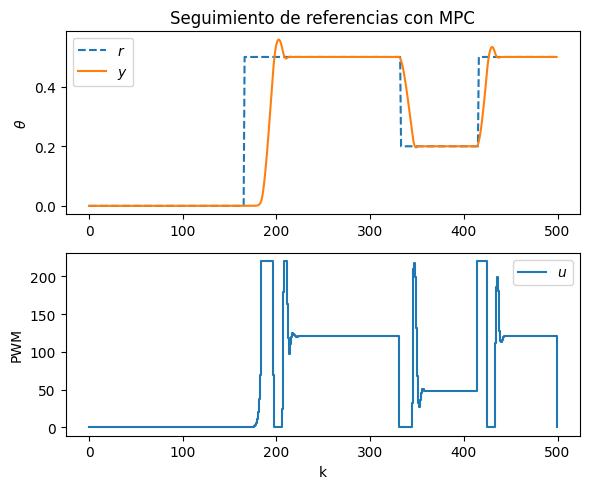

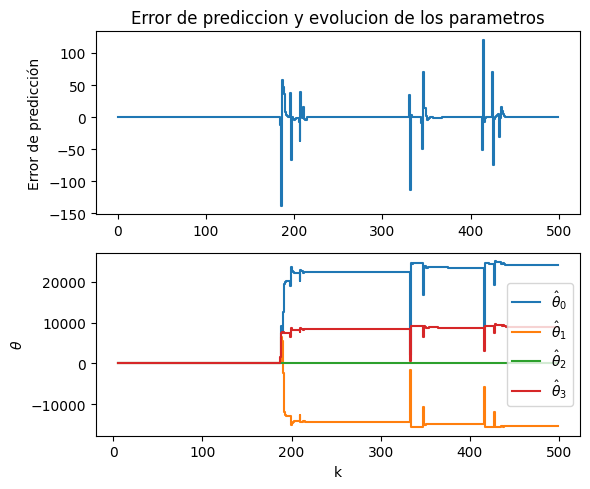

In [54]:
def simularControlPredictivoPonderadoAdaptativo(A, Bp, d, r, v=None, lambda_b0 = 0, alpha=0.95, deltaA=None, deltaB=None, umax=None, plot=True, title=None):
    """
    Simula un controlador predictivo ponderado adaptativo (RLS) para un modelo ARX.

    Entradas:
      - A: vector de coeficientes del polinomio A (mónico) [1, a1, a2, ...]
      - Bp: vector de coeficientes del polinomio B (incluye b0,b1,...)
      - d: delay (nk) en muestras
      - r: referencia (vector de longitud N)
      - v: perturbación aditiva sobre la acción de control (opcional)
      - lambda_b0: factor de ponderación aplicado a b0 (para regularización)
      - alpha: factor de olvido del RLS (0<alpha<=1)
      - deltaA, deltaB: vectores de variación en A y Bp aplicados on-line (opcional)
      - umax: saturación absoluta de la acción de control (opcional)
      - plot: si True dibuja resultados al final
      - title: título opcional para la figura

    Salidas:
      - y: salida simulada
      - u: acción de control usada (no saturada)
    """

    # copias locales del modelo (se actualizan si se pasan deltaA/deltaB)
    A_ = A.copy()
    Bp_ = Bp.copy()

    na = len(A)          # número de coeficientes de A
    nb = len(Bp)         # número de coeficientes de Bp
    nu = (nb-1) + (d-1)  # número de términos de control en el regresor
    npar = na - 1 + nu + 1   # cantidad de parámetros que estima el RLS (salidas pasadas + controles + término extra)

    # señales y buffers
    N = len(r)
    k = np.arange(N)
    u = np.zeros(N)      # acción de control calculada por la ley
    uv = np.zeros(N)     # acción de control efectivamente aplicada (u + v, y saturación)
    y = np.zeros(N)      # salida de la planta
    err = np.zeros(N)    # vector donde se guarda el error de identificación (desplazado)

    # inicialización RLS para estimación de parámetros del controlador
    theta_hat = np.zeros(npar)      # estimación actual de parámetros
    theta_hat[-1] = 0.01            # pequeña semilla en último parámetro para evitar singularidades
    theta_hist = []                 # historial de theta (para mostrar)
    theta_real_hist = []            # historial de theta "teórico" basado en el modelo
    P = 100 * np.eye(npar)          # matriz de covarianza inicial (gran incertidumbre)

    # bucle de simulación: arrancamos en índice suficiente para disponer de históricos
    for kk in range(npar, N-1):
        # --- Construcción del vector de regresores para la etapa de identificación (phiC_est)
        # contiene: -y[k-d], -y[k-d-1], ..., -u[k-1-d], ..., y[k] + lambda_b0*u[k-d]
        phiC_est = np.r_[
            -y[kk-d:kk-d-na+1:-1],                 # salidas pasadas (con signo -)
            -u[kk-1-d:kk-1-d-nu:-1],               # controles pasados (con signo -)
            y[kk] + lambda_b0 * u[kk-d]            # término que incluye la salida actual y la ponderación
        ]

        # --- Error de identificación (u medido menos u predicho por el estimador)
        # se guarda desplazado en err para alinear tiempos (kk-d)
        err[kk-d] = u[kk-d] - phiC_est @ theta_hat

        # --- Actualización RLS (ganancia K, actualización theta_hat y P)
        K = (P @ phiC_est) / (alpha + phiC_est.T @ P @ phiC_est)   # ganancia RLS
        theta_hat = theta_hat + K * err[kk-d]                    # nueva estimación
        P = (P - np.outer(K, phiC_est) @ P) / alpha              # actualización de covarianza
        theta_hist.append(theta_hat.copy())

        # --- Construcción del vector de regresores para la ley de control (phiC)
        # contiene: -y[k], -y[k-1], ..., -u[k-1], ..., referencia futura r[k+d]
        phiC = np.r_[
            -y[kk:kk-na+1:-1],                         # salidas pasadas (con signo -)
            -u[kk-1:kk-1-nu:-1],                       # controles pasados (con signo -)
            (r[kk+d] if kk < N - d else r[-1])         # referencia a futuro (o último valor si no existe)
        ]

        # --- Ley de control: acción calculada con los parámetros estimados
        u[kk] = phiC @ theta_hat

        # --- Aplicación saturación opcional
        if umax is not None and np.abs(u[kk]) > umax:
            u[kk] = np.sign(u[kk]) * umax

        if u[kk] < 0:
            u[kk] = 0

        # --- Aplicación de perturbación sobre la acción opcional
        uv[kk] = u[kk] + (v[kk] if v is not None else 0)

        # --- Si se proveen variaciones del modelo, aplicarlas on-line
        if deltaA is not None:
            A_[1:] = A[1:] * (1 + deltaA[kk])   # modifica solo los coeficientes dinámicos
        if deltaB is not None:
            Bp_ = Bp * (1 + deltaB[kk])         # modifica Bp completo

        # --- Cálculo de theta "real" teórico para monitorización (opcional)
        lambda_ = lambda_b0 * Bp_[0]
        F, G, FBp = calcularPolinomiosPredictivo(A_, Bp_, d)
        theta_real = Bp_[0] / (Bp_[0]**2 + lambda_) * np.r_[G, FBp[1:], 1]
        theta_real_hist.append(theta_real.copy())

        # --- Simulación de la planta (modelo ARX) para obtener y[k+1]
        y[kk+1] = a0*y[kk] + a1*y[kk-1] + b0*(uv[kk])

    # --- Ploteo de resultados (opcional)
    if plot:
        plt.figure(figsize=(6,5))
        plt.subplot(211)
        plt.title("Seguimiento de referencias con MPC")
        plt.plot(k, r, '--', label='$r$')
        plt.plot(k, y, label='$y$')
        plt.ylabel('$\\theta$')

        ymin, ymax = np.min(y[int(N/3):]), np.max(y[int(N/3):])
      #  plt.ylim(ymin - 0.1*(ymax-ymin), ymax + 0.1*(ymax-ymin));
        if title is not None:
            plt.title(title)
        plt.legend()

        plt.subplot(212)
        plt.step(k, u, label='$u$', where='post')
        umin, umax = np.min(u[int(N/3):]), np.max(u[int(N/3):])
        #plt.ylim(umin - 0.1*(umax-umin), umax + 0.1*(umax-umin));
        plt.legend()
        plt.xlabel('k')
        plt.ylabel('PWM')
        plt.tight_layout()
        plt.show()

        # mostrar evolución de theta y error de predicción
        theta_hist = np.array(theta_hist)
        theta_real_hist = np.array(theta_real_hist)
        plt.figure(figsize=(6,5))
        plt.subplot(211)
        plt.title('Error de prediccion y evolucion de los parametros')
        plt.step(k, err, where='post')
        if title is not None:
            plt.title('Evolución de la estimación')
        plt.ylabel('Error de predicción')
        plt.subplot(212)
        colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
        for idx_n in range(npar):
            color = colors[idx_n % len(colors)]
            plt.step(k[-len(theta_hist):], theta_hist[:, idx_n], color=color, label=f"$\\hat{{\\theta}}_{idx_n}$", where='post')
        #    plt.step(k[-len(theta_real_hist):], theta_real_hist[:, idx_n], '--', color=color, where='post')
        plt.xlabel('k')
        plt.ylabel('$\\theta$')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return y, u


A = np.r_[1, a0, a1]
Bp = 2 * np.r_[b0]
d = 2

N = 500
k = np.arange(N)
r = 0.5*np.ones_like(k)  # de 0 a 1
r[:(len(r)//3)] = 0
r[len(r)*2//3:] = 0.2
r[len(r)*5//6:] = 0.5


deltaA = np.zeros(N)
deltaB = np.zeros(N)
deltaA[int(N*2/3):] = 0.05
deltaB[int(N*1/3):] = 0.05

_,_ = simularControlPredictivoPonderadoAdaptativo(A,Bp,d,r,lambda_b0=0,deltaA=deltaA,deltaB=deltaB, umax=220)